In [1]:
import time

start = time.time()
import numpy as np
print("numpy:", time.time() - start)

start = time.time()
import pandas as pd
print("pandas:", time.time() - start)

start = time.time()
import sklearn
print("sklearn:", time.time() - start)

numpy: 0.42528557777404785
pandas: 1.168694019317627
sklearn: 2.9578654766082764


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report

In [68]:
df = pd.read_csv('adult.csv')

<Axes: xlabel='income'>

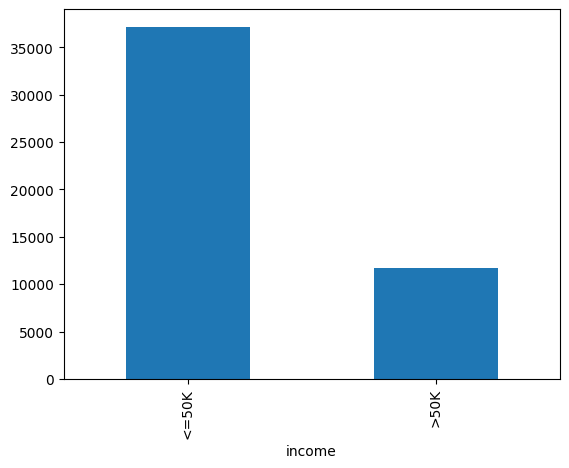

In [69]:
df['income'].value_counts().plot(kind='bar')

In [70]:
X = df.drop('income',axis=1)
y = df.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [72]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
cat_cols = X_train.select_dtypes(include='object')
X_train = ohe.fit_transform(X_train)
X_test  = ohe.transform(X_test)

AttributeError: 'csr_matrix' object has no attribute 'select_dtypes'

In [61]:
bgr = BaggingClassifier(estimator = DecisionTreeClassifier(class_weight='balanced'),
                       n_estimators=500,
                       max_samples=0.5,
                       bootstrap=True,
                       n_jobs=-1,
                       verbose=1
                       )

In [62]:
bgr.fit(X_train,y_train)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:  1.4min remaining:  9.6min
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:  1.4min finished


,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ht='balanced')
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",500
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.5
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",1


In [31]:
y_pred = bgr.predict(X_test)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:    2.6s remaining:   18.6s
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:   10.4s finished


In [37]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           1       1.00      1.00      1.00     13810\n\n    accuracy                           1.00     13810\n   macro avg       1.00      1.00      1.00     13810\nweighted avg       1.00      1.00      1.00     13810\n'

<Axes: xlabel='income'>

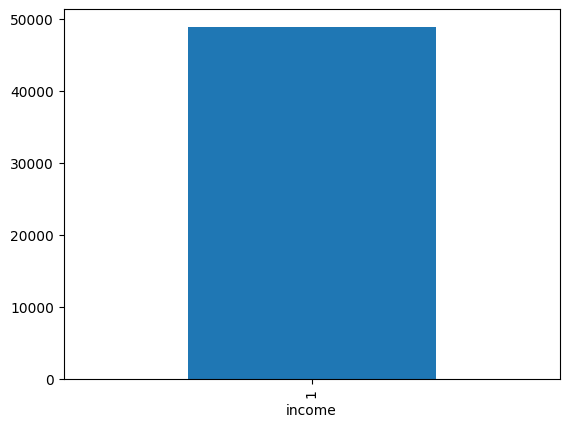

In [44]:
df['income'].value_counts().plot(kind='bar')